In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
train=pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')

In [3]:
test=pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [4]:
train.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
train.shape

(594194, 21)

In [6]:
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [8]:
train['Churn'].value_counts(normalize=True)

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

In training data, the classes are imbalanced, they are of 77% No and 22% yes

In [9]:
train.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [10]:
train.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
train.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
numeric_cols = train.select_dtypes(include='number').columns.tolist()
numeric_cols

['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [13]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [14]:
numeric_cols = [c for c in numeric_cols 
                if c not in ['id', 'SeniorCitizen']]

In [15]:
train['SeniorCitizen'].value_counts()

SeniorCitizen
0    526395
1     67799
Name: count, dtype: int64

In [16]:
for col in numeric_cols:
    Q1  = train[col].quantile(0.25)
    Q3  = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[
        (train[col] < lower_bound) | 
        (train[col] > upper_bound)
    ]
    
    outlier_pct = len(outliers) / len(train) * 100
    
    print(f"Column: {col}")
    print(f"  Q1:          {Q1:.2f}")
    print(f"  Q3:          {Q3:.2f}")
    print(f"  IQR:         {IQR:.2f}")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Outliers:    {len(outliers):,} ({outlier_pct:.1f}%)")
    
    if outlier_pct > 5:
        print(f" High outlier rate! Consider capping or log transform")
    elif outlier_pct > 0:
        print(f"Some outliers present, monitor")
    else:
        print(f"No outliers detected")
    print()

Column: tenure
  Q1:          12.00
  Q3:          62.00
  IQR:         50.00
  Lower bound: -63.00
  Upper bound: 137.00
  Outliers:    0 (0.0%)
No outliers detected

Column: MonthlyCharges
  Q1:          29.90
  Q3:          90.80
  IQR:         60.90
  Lower bound: -61.45
  Upper bound: 182.15
  Outliers:    0 (0.0%)
No outliers detected

Column: TotalCharges
  Q1:          639.65
  Q3:          4263.80
  IQR:         3624.15
  Lower bound: -4796.58
  Upper bound: 9700.03
  Outliers:    0 (0.0%)
No outliers detected



In [17]:
# ============================================
# PART A — Central Tendency
# ============================================
print("=" * 60)
print("PART A — Mean, Median, Mode + Skewness")
print("=" * 60)

for col in numeric_cols:
    mean   = train[col].mean()
    median = train[col].median()
    mode   = train[col].mode()[0]
    skew   = train[col].skew()
    
    # Interpret skewness
    if skew > 1:
        skew_label = 'highly right skewed ⚠️'
    elif skew > 0.5:
        skew_label = 'moderately right skewed'
    elif skew < -1:
        skew_label = 'highly left skewed ⚠️'
    elif skew < -0.5:
        skew_label = 'moderately left skewed'
    else:
        skew_label = 'roughly symmetric ✅'
    
    print(f"Column: {col}")
    print(f"  Mean: {mean:.2f}")
    print(f"  Median: {median:.2f}")
    print(f"  Mode: {mode:.2f}")
    print(f"  Skewness:{skew:.2f} → {skew_label}")
    
    # Flag if mean and median differ a lot
    diff_pct = abs(mean - median) / median * 100
    if diff_pct > 10:
        print(f"Mean and Median differ by {diff_pct:.1f}%")
        print(f"outliers or skewness present")
    print()


PART A — Mean, Median, Mode + Skewness
Column: tenure
  Mean: 36.58
  Median: 35.00
  Mode: 72.00
  Skewness:0.06 → roughly symmetric ✅

Column: MonthlyCharges
  Mean: 65.87
  Median: 74.10
  Mode: 20.05
  Skewness:-0.29 → roughly symmetric ✅
Mean and Median differ by 11.1%
outliers or skewness present

Column: TotalCharges
  Mean: 2494.38
  Median: 1433.65
  Mode: 6096.90
  Skewness:0.91 → moderately right skewed
Mean and Median differ by 74.0%
outliers or skewness present



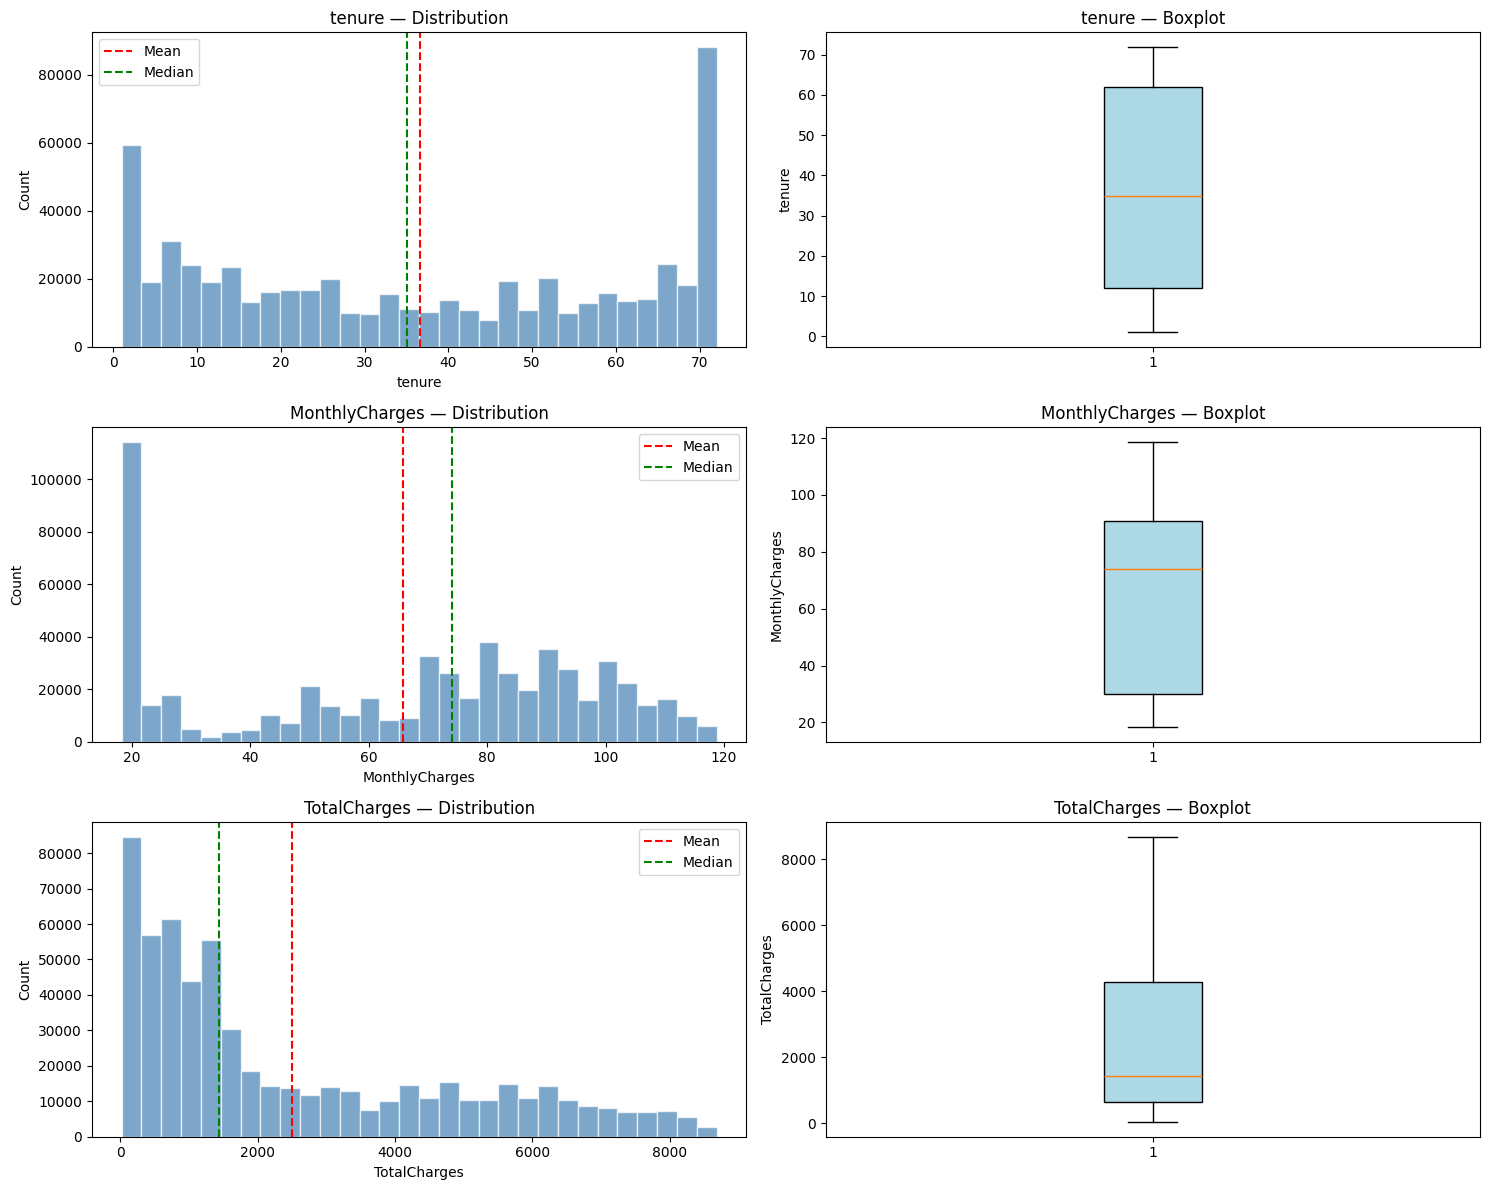

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    len(numeric_cols), 2, 
    figsize=(15, 4 * len(numeric_cols))
)

for i, col in enumerate(numeric_cols):
    
    # Plot 1 — Histogram with KDE
    axes[i,0].hist(train[col], bins=30, 
                   color='steelblue', edgecolor='white',
                   alpha=0.7)
    axes[i,0].axvline(train[col].mean(), 
                      color='red', linestyle='--', 
                      label='Mean')
    axes[i,0].axvline(train[col].median(), 
                      color='green', linestyle='--', 
                      label='Median')
    axes[i,0].set_title(f'{col} — Distribution')
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel('Count')
    axes[i,0].legend()
    
    # Plot 2 — Boxplot (shows outliers visually)
    axes[i,1].boxplot(train[col].dropna(), 
                      vert=True,
                      patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))
    axes[i,1].set_title(f'{col} — Boxplot')
    axes[i,1].set_ylabel(col) 
plt.tight_layout()
plt.show()

## Observation
Tenure Analysis
- Mode is 72 which means many customers stay for full 72 months (6 years). Two types of customers — those who leave early and those who stay forever. This is called bimodal distribution

Monthly Charges Analysis

- Mode of 20.05 means many customers are on basic cheap plan. But median of 74 means most paying customers pay quite a lot. Two customer segments visible here.

TotalCharges Analysis

- This is the most problematic column. Mean and median differ by 74% — that's massive. This means extreme high values are pulling the mean up heavily.


In [19]:
train['Churn'] = train['Churn'].map({'Yes': 1, 'No': 0})

# Verify it worked
print("After encoding:")
print(train['Churn'].unique())
print(train['Churn'].value_counts())

After encoding:
[0 1]
Churn
0    460377
1    133817
Name: count, dtype: int64


LOG TRANSFORM — TotalCharges

BEFORE:
  Skewness: 0.909
  Mean:     2494.38
  Median:   1433.65
  Differ:   74.0%

AFTER:
  Skewness: -0.785
  Mean:     7.18
  Median:   7.27
  Differ:   1.2%

Skewness improved by: 0.124 ✅


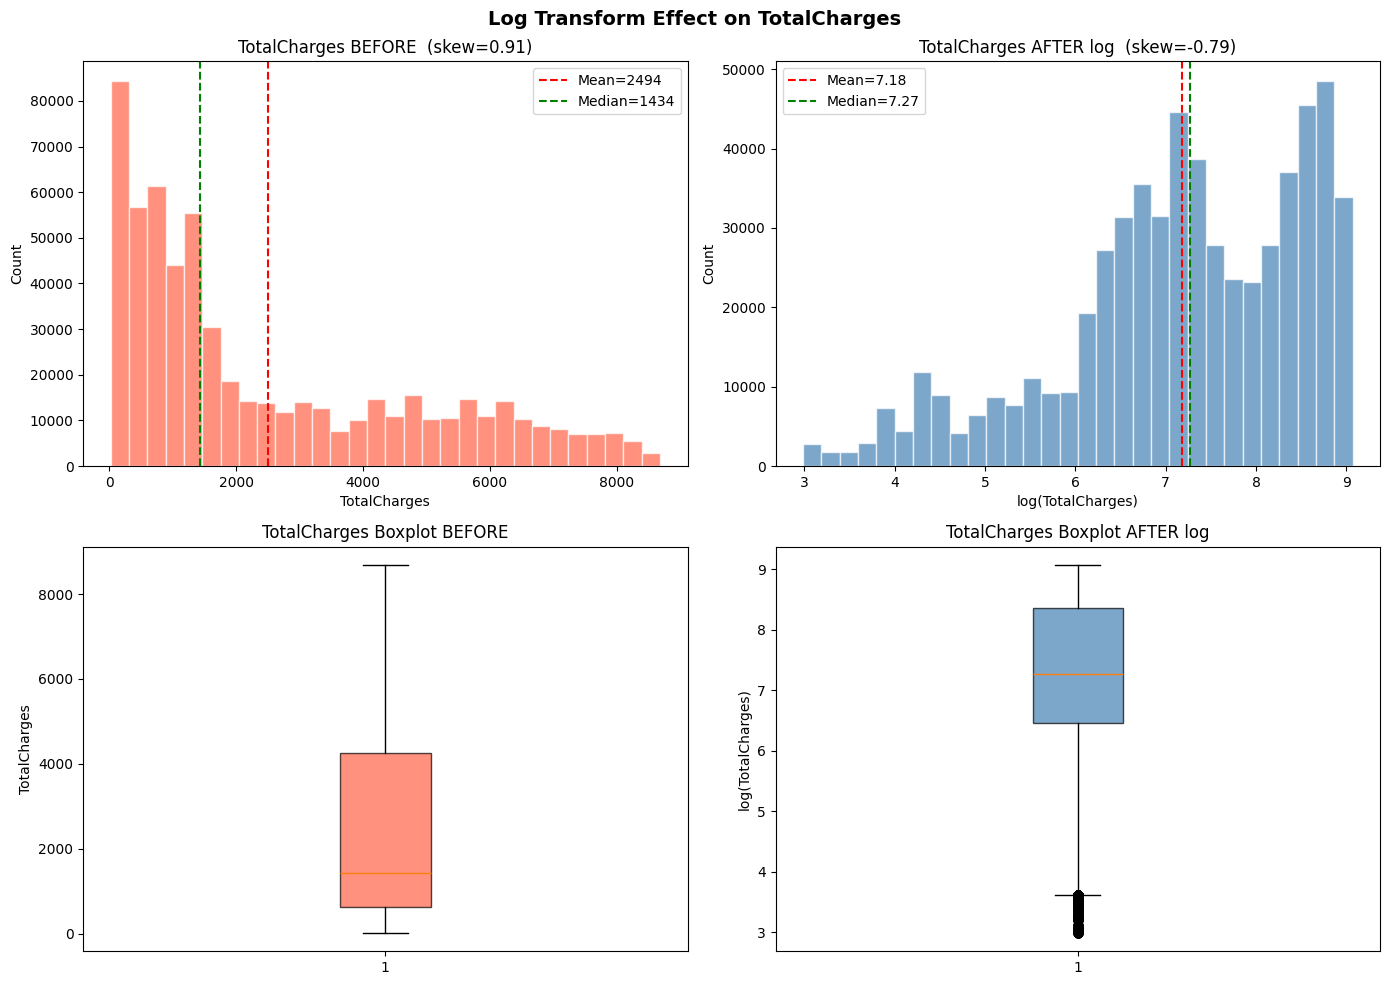

CHURN VS NO CHURN — All 3 Continuous Features


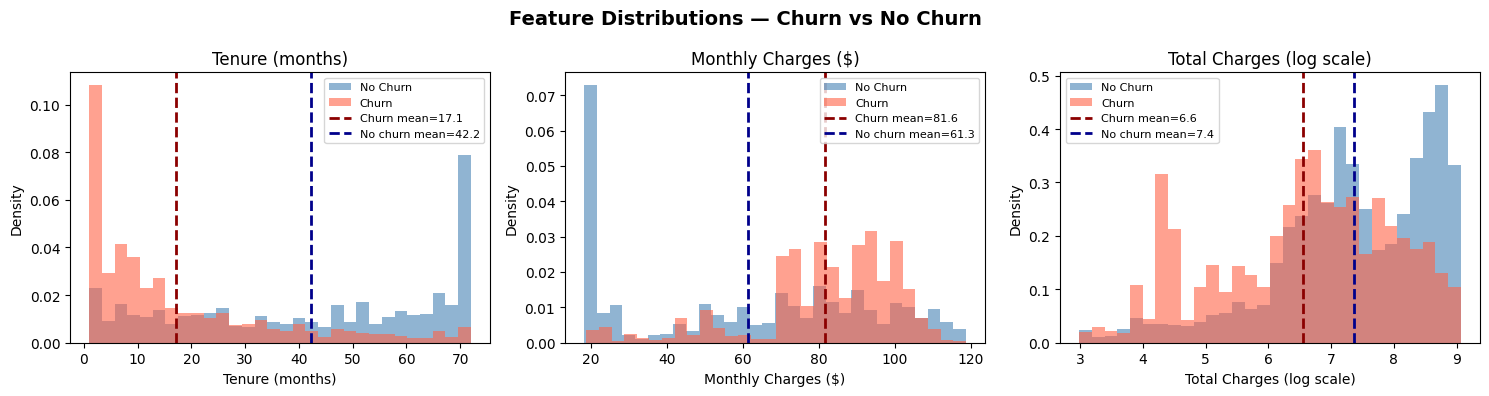


KEY INSIGHTS TO LOOK FOR:
  tenure          → churners peak at LOW values?
  MonthlyCharges  → churners peak at HIGH values?
  TotalCharges    → churners peak at LOW log values?


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  

# OR try this instead
%matplotlib inline

print("=" * 60)
print("LOG TRANSFORM — TotalCharges")
print("=" * 60)
print()

# Before transform
skew_before = train['TotalCharges'].skew()
mean_before = train['TotalCharges'].mean()
med_before  = train['TotalCharges'].median()

print(f"BEFORE:")
print(f"  Skewness: {skew_before:.3f}")
print(f"  Mean:     {mean_before:.2f}")
print(f"  Median:   {med_before:.2f}")
print(f"  Differ:   {abs(mean_before-med_before)/med_before*100:.1f}%")
print()

# Apply log transform
train['TotalCharges_log'] = np.log1p(train['TotalCharges'])
test['TotalCharges_log']  = np.log1p(test['TotalCharges'])

# After transform
skew_after = train['TotalCharges_log'].skew()
mean_after = train['TotalCharges_log'].mean()
med_after  = train['TotalCharges_log'].median()

print(f"AFTER:")
print(f"  Skewness: {skew_after:.3f}")
print(f"  Mean:     {mean_after:.2f}")
print(f"  Median:   {med_after:.2f}")
print(f"  Differ:   {abs(mean_after-med_after)/med_after*100:.1f}%")
print()

# How much did skewness improve?
improvement = abs(skew_before) - abs(skew_after)
print(f"Skewness improved by: {improvement:.3f} ✅")

# ============================================
# VISUALIZE BEFORE AND AFTER
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Histogram before
axes[0,0].hist(train['TotalCharges'], bins=30,
               color='tomato', edgecolor='white', alpha=0.7)
axes[0,0].axvline(mean_before, color='red',
                  linestyle='--', label=f'Mean={mean_before:.0f}')
axes[0,0].axvline(med_before,  color='green',
                  linestyle='--', label=f'Median={med_before:.0f}')
axes[0,0].set_title(f'TotalCharges BEFORE  (skew={skew_before:.2f})')
axes[0,0].set_xlabel('TotalCharges')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Plot 2 — Histogram after
axes[0,1].hist(train['TotalCharges_log'], bins=30,
               color='steelblue', edgecolor='white', alpha=0.7)
axes[0,1].axvline(mean_after, color='red',
                  linestyle='--', label=f'Mean={mean_after:.2f}')
axes[0,1].axvline(med_after,  color='green',
                  linestyle='--', label=f'Median={med_after:.2f}')
axes[0,1].set_title(f'TotalCharges AFTER log  (skew={skew_after:.2f})')
axes[0,1].set_xlabel('log(TotalCharges)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Plot 3 — Boxplot before
axes[1,0].boxplot(train['TotalCharges'].dropna(),
                  patch_artist=True,
                  boxprops=dict(facecolor='tomato', alpha=0.7))
axes[1,0].set_title('TotalCharges Boxplot BEFORE')
axes[1,0].set_ylabel('TotalCharges')

# Plot 4 — Boxplot after
axes[1,1].boxplot(train['TotalCharges_log'].dropna(),
                  patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1,1].set_title('TotalCharges Boxplot AFTER log')
axes[1,1].set_ylabel('log(TotalCharges)')

plt.suptitle('Log Transform Effect on TotalCharges',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# CHURN VS NO CHURN AFTER TRANSFORM
# ============================================
print("=" * 60)
print("CHURN VS NO CHURN — All 3 Continuous Features")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_cols = {
    'tenure'            : 'Tenure (months)',
    'MonthlyCharges'    : 'Monthly Charges ($)',
    'TotalCharges_log'  : 'Total Charges (log scale)'
}

for i, (col, label) in enumerate(plot_cols.items()):
    churn_yes = train[train['Churn']==1][col]
    churn_no  = train[train['Churn']==0][col]

    axes[i].hist(churn_no,  bins=30, alpha=0.6,
                 color='steelblue', label='No Churn',
                 density=True)
    axes[i].hist(churn_yes, bins=30, alpha=0.6,
                 color='tomato', label='Churn',
                 density=True)

    # Add mean lines
    axes[i].axvline(churn_yes.mean(), color='darkred',
                    linestyle='--', linewidth=2,
                    label=f'Churn mean={churn_yes.mean():.1f}')
    axes[i].axvline(churn_no.mean(),  color='darkblue',
                    linestyle='--', linewidth=2,
                    label=f'No churn mean={churn_no.mean():.1f}')

    axes[i].set_title(label)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions — Churn vs No Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("KEY INSIGHTS TO LOOK FOR:")
print("  tenure          → churners peak at LOW values?")
print("  MonthlyCharges  → churners peak at HIGH values?")
print("  TotalCharges    → churners peak at LOW log values?")


Churn mean:    17.1 months  ← leave early!
No churn mean: 42.2 months  ← stay long!

Difference: 25 months gap!

Plot shows:
  Red (churn) peaks at 0-10 months
  Blue (no churn) peaks at 60-72 month

Churn mean:    81.6  ← paying more!
No churn mean: 61.3  ← paying less!

Difference: $20 per month gap!

Plot shows:
  Red (churn) peaks at $80-100 range
  Blue (no churn) peaks at $20-30 range

Churn mean:    6.6
No churn mean: 7.4

Plot shows:
  Red (churn) peaks at log 3-5 (low total)
  Blue (no churn) peaks at log 7-9 (high total)

🚨 High Risk Customer Profile:
  → New customer (tenure < 10 months)
  → Paying high monthly charges ($80+)
  → Low total charges (hasn't paid much yet)

✅ Safe Customer Profile:
  → Long tenure (40+ months)
  → Lower monthly charges ($20-40)
  → High total charges (loyal long term)

## Categorical EDA

In [21]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [22]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols 
            if c not in ['id', 'customerID', 'Churn']]

print(f"Categorical columns: {len(cat_cols)}")
print(cat_cols)

Categorical columns: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [23]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# For each categorical column
for col in cat_cols:
    print("=" * 40)
    print(f"Column: {col}")
    print()
    
    # 1. Value counts
    print("Counts:")
    print(train[col].value_counts())
    print()
    
    # 2. Churn rate per category
    churn_rate = train.groupby(col)['Churn'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)
    print("Churn rate %:")
    print(churn_rate.round(1))
    print()

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Column: gender

Counts:
gender
Female    298738
Male      295456
Name: count, dtype: int64

Churn rate %:
gender
Female    22.8
Male      22.2
Name: Churn, dtype: float64

Column: Partner

Counts:
Partner
Yes    309554
No     284640
Name: count, dtype: int64

Churn rate %:
Partner
No     32.5
Yes    13.4
Name: Churn, dtype: float64

Column: Dependents

Counts:
Dependents
No     414362
Yes    179832
Name: count, dtype: int64

Churn rate %:
Dependents
No     29.1
Yes     7.3
Name: Churn, dtype: float64

Column: PhoneService

Counts:
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64

Churn rate %:
PhoneService
Yes    22.9
No     16.8
Name: Churn, dtype: float64

Column: MultipleLines

Counts:
MultipleLines
No       

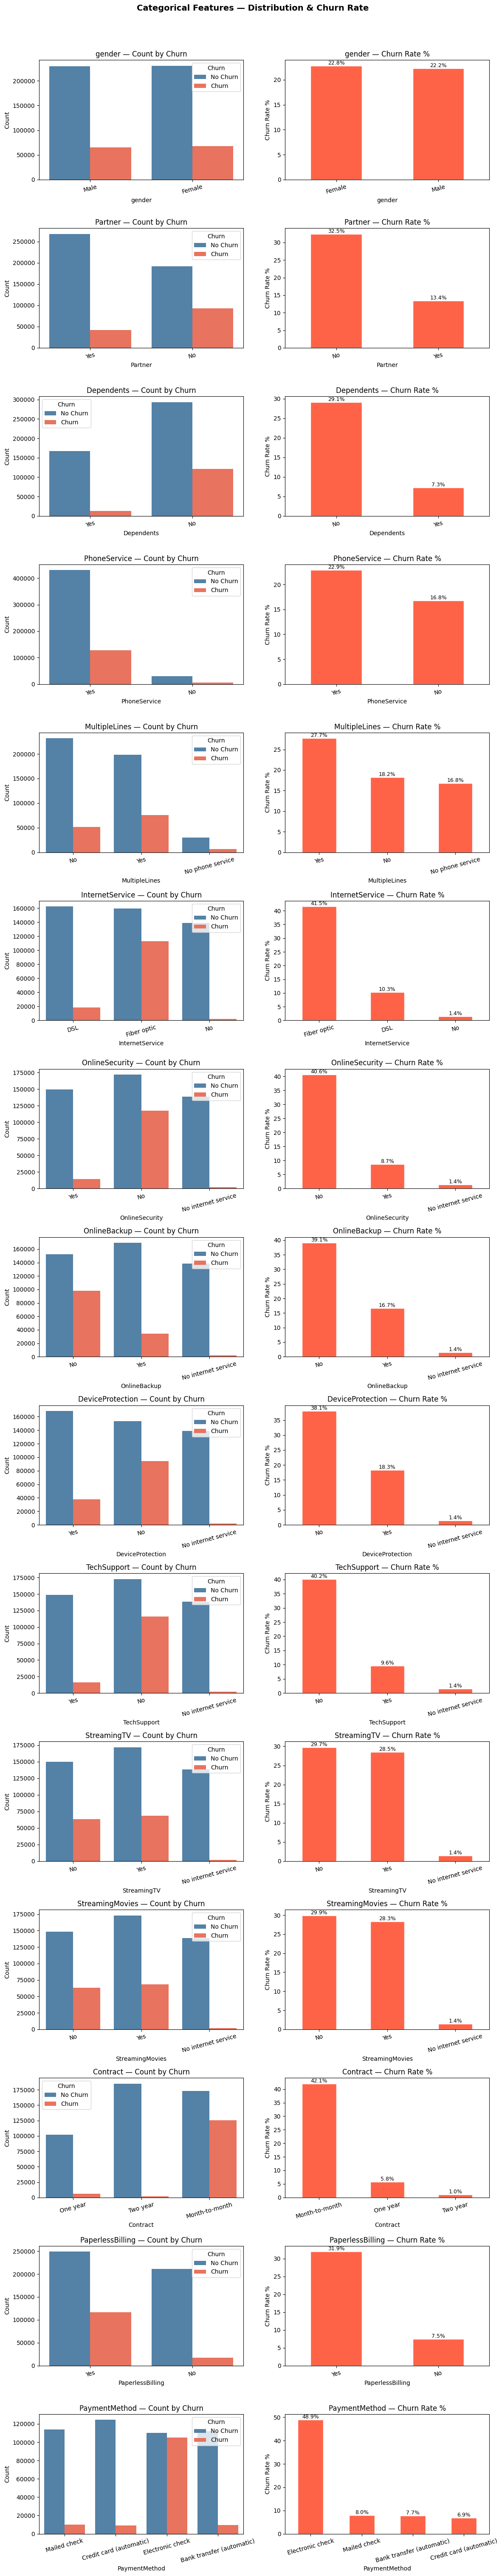

In [24]:
import seaborn as sns

fig, axes = plt.subplots(len(cat_cols), 2,
                         figsize=(12, len(cat_cols) * 4))

for i, col in enumerate(cat_cols):
    
    # Plot 1 — count split by churn
    sns.countplot(data=train,
                  x=col,
                  hue='Churn',
                  ax=axes[i, 0],
                  palette=['steelblue','tomato'])
    
    axes[i, 0].set_title(f'{col} — Count by Churn')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].legend(title='Churn', 
                      labels=['No Churn','Churn'])
    
    # Rotate x labels if too long
    axes[i, 0].tick_params(axis='x', rotation=15)
    
    # Plot 2 — churn rate per category
    churn_rate = train.groupby(col)['Churn'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)
    
    churn_rate.plot(kind='bar',
                    ax=axes[i, 1],
                    color='tomato',
                    edgecolor='white')
    
    axes[i, 1].set_title(f'{col} — Churn Rate %')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Churn Rate %')
    axes[i, 1].tick_params(axis='x', rotation=15)
    
    # Add % labels on bars
    for p in axes[i, 1].patches:
        axes[i, 1].annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Categorical Features — Distribution & Churn Rate',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Label Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder

# Make copies to preserve original
train_enc = train.copy()
test_enc  = test.copy()

# Get categorical columns
cat_cols = train_enc.select_dtypes(
                include='object').columns.tolist()
cat_cols = [c for c in cat_cols 
            if c not in ['id', 'customerID', 'Churn']]

print(f"Columns to encode: {len(cat_cols)}")
print()

# Encode each column
le = LabelEncoder()

for col in cat_cols:
    train_enc[col] = le.fit_transform(train_enc[col])
    test_enc[col]  = le.transform(test_enc[col])

print("Before encoding:")
print(train[['gender', 'Contract']].head(3))
print()
print("After encoding:")
print(train_enc[['gender', 'Contract']].head(3))
print()
print("✅ Encoding done!")

Columns to encode: 15

Before encoding:
  gender        Contract
0   Male        One year
1   Male        Two year
2   Male  Month-to-month

After encoding:
   gender  Contract
0       1         1
1       1         2
2       1         0

✅ Encoding done!


In [26]:
# Define features to use
FEATURES = [col for col in train_enc.columns
            if col not in ['id', 'customerID',
                           'Churn', 'TotalCharges']]

# Why exclude TotalCharges?
# We created TotalCharges_log already
# Using both would be redundant!

# Prepare X and y
X      = train_enc[FEATURES]
y      = train_enc['Churn']
X_test = test_enc[FEATURES]

print("Features used:")
for i, f in enumerate(FEATURES):
    print(f"  {i+1}. {f}")

print()
print(f"X shape:      {X.shape}")
print(f"y shape:      {y.shape}")
print(f"X_test shape: {X_test.shape}")
print()
print(f"Churn rate in training: {y.mean()*100:.1f}%")

Features used:
  1. gender
  2. SeniorCitizen
  3. Partner
  4. Dependents
  5. tenure
  6. PhoneService
  7. MultipleLines
  8. InternetService
  9. OnlineSecurity
  10. OnlineBackup
  11. DeviceProtection
  12. TechSupport
  13. StreamingTV
  14. StreamingMovies
  15. Contract
  16. PaperlessBilling
  17. PaymentMethod
  18. MonthlyCharges
  19. TotalCharges_log

X shape:      (594194, 19)
y shape:      (594194,)
X_test shape: (254655, 19)

Churn rate in training: 22.5%


## Stratified 5 fold cross validation

In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import numpy as np

# Settings
N_FOLDS    = 5
RANDOM_STATE = 42

# Storage
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

# StratifiedKFold object
skf = StratifiedKFold(
    n_splits   = N_FOLDS,
    shuffle    = True,
    random_state = RANDOM_STATE
)

print(f"Starting {N_FOLDS}-Fold Cross Validation...")
print(f"Total training rows: {len(X):,}")
print(f"Each fold trains on: {len(X)*4//5:,} rows")
print(f"Each fold tests on:  {len(X)//5:,} rows")
print()

Starting 5-Fold Cross Validation...
Total training rows: 594,194
Each fold trains on: 475,355 rows
Each fold tests on:  118,838 rows



## Training Loop

In [41]:
# Training loop
for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)):
    
    print(f"Fold {fold+1}/{N_FOLDS}")
    
    # Split this fold
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_val   = y.iloc[val_idx]
    
    print(f"  Train size: {len(X_train):,}")
    print(f"  Val size:   {len(X_val):,}")
    print(f"  Churn rate in train: "
          f"{y_train.mean()*100:.1f}%")
    print(f"  Churn rate in val:   "
          f"{y_val.mean()*100:.1f}%")
    
    # XGBoost model
    model = xgb.XGBClassifier(
        n_estimators         = 500,
        max_depth            = 4,
        learning_rate        = 0.05,
        subsample            = 0.8,
        colsample_bytree     = 0.8,
        scale_pos_weight     = len(y_train[y_train==0]) /
                               len(y_train[y_train==1]),
        eval_metric          = 'auc',
        early_stopping_rounds= 50,
        random_state         = RANDOM_STATE
    )
    
    # Train model
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Predict on validation
    val_pred = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)
    
    # Store predictions
    oof_preds[val_idx]  = val_pred
    test_preds         += model.predict_proba(
                              X_test)[:, 1] / N_FOLDS
    
    print(f"  AUC:            {fold_auc:.4f}")
    print(f"  Best iteration: {model.best_iteration}")
    print()

print("✅ Training complete!")

Fold 1/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9151
  Best iteration: 499

Fold 2/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9163
  Best iteration: 499

Fold 3/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9158
  Best iteration: 498

Fold 4/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9167
  Best iteration: 499

Fold 5/5
  Train size: 475,356
  Val size:   118,838
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9141
  Best iteration: 499

✅ Training complete!


In [43]:
# Training loop
for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)):
    
    print(f"Fold {fold+1}/{N_FOLDS}")
    
    # Split this fold
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_val   = y.iloc[val_idx]
    
    print(f"  Train size: {len(X_train):,}")
    print(f"  Val size:   {len(X_val):,}")
    print(f"  Churn rate in train: "
          f"{y_train.mean()*100:.1f}%")
    print(f"  Churn rate in val:   "
          f"{y_val.mean()*100:.1f}%")
    
    # XGBoost model
    model = xgb.XGBClassifier(
        n_estimators         = 2000,
        max_depth            = 4,
        learning_rate        = 0.05,
        subsample            = 0.8,
        colsample_bytree     = 0.8,
        scale_pos_weight     = len(y_train[y_train==0]) /
                               len(y_train[y_train==1]),
        eval_metric          = 'auc',
        early_stopping_rounds= 50,
        random_state         = RANDOM_STATE
    )
    
    # Train model
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Predict on validation
    val_pred = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)
    
    # Store predictions
    oof_preds[val_idx]  = val_pred
    test_preds         += model.predict_proba(
                              X_test)[:, 1] / N_FOLDS
    
    print(f"  AUC:            {fold_auc:.4f}")
    print(f"  Best iteration: {model.best_iteration}")
    print()

print("✅ Training complete!")

Fold 1/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9160
  Best iteration: 1418

Fold 2/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9170
  Best iteration: 1253

Fold 3/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9166
  Best iteration: 1310

Fold 4/5
  Train size: 475,355
  Val size:   118,839
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9176
  Best iteration: 1616

Fold 5/5
  Train size: 475,356
  Val size:   118,838
  Churn rate in train: 22.5%
  Churn rate in val:   22.5%
  AUC:            0.9150
  Best iteration: 1519

✅ Training complete!


In [ ]:
# Training loop
for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)):
    
    print(f"Fold {fold+1}/{N_FOLDS}")
    
    # Split this fold
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_val   = y.iloc[val_idx]
    
    print(f"  Train size: {len(X_train):,}")
    print(f"  Val size:   {len(X_val):,}")
    print(f"  Churn rate in train: "
          f"{y_train.mean()*100:.1f}%")
    print(f"  Churn rate in val:   "
          f"{y_val.mean()*100:.1f}%")
    
    # XGBoost model
    model = xgb.XGBClassifier(
        n_estimators         = 1000,
        max_depth            = 4,
        learning_rate        = 0.01,
        subsample            = 0.8,
        colsample_bytree     = 0.8,
        scale_pos_weight     = len(y_train[y_train==0]) /
                               len(y_train[y_train==1]),
        eval_metric          = 'auc',
        early_stopping_rounds= 50,
        random_state         = RANDOM_STATE
    )
    
    # Train model
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Predict on validation
    val_pred = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)
    
    # Store predictions
    oof_preds[val_idx]  = val_pred
    test_preds         += model.predict_proba(
                              X_test)[:, 1] / N_FOLDS
    
    print(f"  AUC:            {fold_auc:.4f}")
    print(f"  Best iteration: {model.best_iteration}")
    print()

print("✅ Training complete!")

In [44]:
print("=" * 50)
print("GENERATING SUBMISSION")
print("=" * 50)
print()

# Check test predictions look reasonable
print(f"Test predictions summary:")
print(f"  Min:  {test_preds.min():.4f}")
print(f"  Max:  {test_preds.max():.4f}")
print(f"  Mean: {test_preds.mean():.4f}")
print(f"  Std:  {test_preds.std():.4f}")
print()

# Create submission dataframe
submission = pd.DataFrame({
    'id'    : test['id'],
    'Churn' : test_preds
})

print("Sample predictions:")
print(submission.head(10).to_string(index=False))
print()

# Save
submission.to_csv('submission.csv', index=False)
print(f"✅ submission.csv saved!")
print(f"   Rows: {len(submission):,}")

GENERATING SUBMISSION

Test predictions summary:
  Min:  0.0009
  Max:  2.9865
  Mean: 1.0275
  Std:  1.0385

Sample predictions:
    id    Churn
594194 0.649533
594195 0.005604
594196 0.839702
594197 0.037410
594198 2.345403
594199 1.187970
594200 2.900609
594201 0.020117
594202 0.346702
594203 1.901276

✅ submission.csv saved!
   Rows: 254,655


In [29]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

print("LightGBM version:", lgb.__version__)
print("✅ LightGBM ready!")

LightGBM version: 4.6.0
✅ LightGBM ready!


In [49]:
# Storage for LightGBM predictions
lgbm_oof_preds  = np.zeros(len(X))
lgbm_test_preds = np.zeros(len(X_test))
lgbm_fold_scores = []

print(f"Starting LightGBM {N_FOLDS}-Fold Training...")
print()

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)):
    
    print(f"Fold {fold+1}/{N_FOLDS}")
    
    # Split data
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_val   = y.iloc[val_idx]
    
    # LightGBM model
    model_lgbm = lgb.LGBMClassifier(
        n_estimators          = 3000,
        max_depth             = 4,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        scale_pos_weight      = len(y_train[y_train==0]) /
                                len(y_train[y_train==1]),
        random_state          = RANDOM_STATE,
        verbose               = -1
    )
    
    # Train with early stopping
    model_lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    
    # Predict
    val_pred  = model_lgbm.predict_proba(X_val)[:, 1]
    fold_auc  = roc_auc_score(y_val, val_pred)
    lgbm_fold_scores.append(fold_auc)
    
    # Store predictions
    lgbm_oof_preds[val_idx]  = val_pred
    lgbm_test_preds          += model_lgbm.predict_proba(
                                    X_test)[:, 1] / N_FOLDS
    
    print(f"  AUC:            {fold_auc:.4f}")
    print(f"  Best iteration: {model_lgbm.best_iteration_}")
    print()

print("✅ LightGBM training complete!")
print()
print(f"LightGBM Mean AUC: {np.mean(lgbm_fold_scores):.4f}")
print(f"LightGBM Std AUC:  {np.std(lgbm_fold_scores):.4f}")


Starting LightGBM 5-Fold Training...

Fold 1/5
  AUC:            0.9069
  Best iteration: 33

Fold 2/5
  AUC:            0.9075
  Best iteration: 30

Fold 3/5
  AUC:            0.9075
  Best iteration: 33

Fold 4/5
  AUC:            0.9088
  Best iteration: 36

Fold 5/5
  AUC:            0.9060
  Best iteration: 32

✅ LightGBM training complete!

LightGBM Mean AUC: 0.9073
LightGBM Std AUC:  0.0009


In [50]:
# Test one fold manually with verbose ON
X_train = X.iloc[:400000]
y_train = y.iloc[:400000]
X_val   = X.iloc[400000:]
y_val   = y.iloc[400000:]

model_test = lgb.LGBMClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbose          = -1
)

model_test.fit(
    X_train, y_train,
    eval_set   = [(X_val, y_val)],
    callbacks  = [
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(period=10)
    ]
)

print(f"Best iteration: {model_test.best_iteration_}")
print(f"Best score:     {model_test.best_score_}")



Training until validation scores don't improve for 50 rounds
[10]	valid_0's binary_logloss: 0.413879
[20]	valid_0's binary_logloss: 0.364341
[30]	valid_0's binary_logloss: 0.338564
[40]	valid_0's binary_logloss: 0.324884
[50]	valid_0's binary_logloss: 0.316541
[60]	valid_0's binary_logloss: 0.31166
[70]	valid_0's binary_logloss: 0.308291
[80]	valid_0's binary_logloss: 0.306184
[90]	valid_0's binary_logloss: 0.304849
[100]	valid_0's binary_logloss: 0.303857
[110]	valid_0's binary_logloss: 0.303152
[120]	valid_0's binary_logloss: 0.302646
[130]	valid_0's binary_logloss: 0.302244
[140]	valid_0's binary_logloss: 0.301806
[150]	valid_0's binary_logloss: 0.301516
[160]	valid_0's binary_logloss: 0.301156
[170]	valid_0's binary_logloss: 0.300903
[180]	valid_0's binary_logloss: 0.30068
[190]	valid_0's binary_logloss: 0.30044
[200]	valid_0's binary_logloss: 0.300307
Did not meet early stopping. Best iteration is:
[200]	valid_0's binary_logloss: 0.300307
Best iteration: 200
Best score:     defaul

In [51]:
model_lgbm = lgb.LGBMClassifier(
    n_estimators     = 3000,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = len(y_train[y_train==0]) /
                       len(y_train[y_train==1]),
    random_state     = RANDOM_STATE,
    verbose          = -1
)

# Place 2 — in fit() call
model_lgbm.fit(
    X_train, y_train,
    eval_set   = [(X_val, y_val)],
    eval_metric = 'auc',            # ← HERE!
    callbacks  = [
        lgb.early_stopping(
            100, 
            verbose=True            # ← see what happens
        ),
        lgb.log_evaluation(period=50)  # every 50 rounds
    ]
)

print(f"Best iteration: {model_lgbm.best_iteration_}")

Training until validation scores don't improve for 100 rounds
[50]	valid_0's auc: 0.908422	valid_0's binary_logloss: 0.379127
[100]	valid_0's auc: 0.911137	valid_0's binary_logloss: 0.380598
Early stopping, best iteration is:
[35]	valid_0's auc: 0.906313	valid_0's binary_logloss: 0.377202
Best iteration: 35


In [52]:
model_test = lgb.LGBMClassifier(
    n_estimators     = 3000,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = len(y_train[y_train==0]) /
                       len(y_train[y_train==1]),
    random_state     = 42,
    verbose          = -1,
    metric           = 'None'    # ← disable default metric!
)

model_test.fit(
    X_train, y_train,
    eval_set    = [(X_val, y_val)],
    eval_metric = 'auc',         # ← ONLY auc now!
    callbacks   = [
        lgb.early_stopping(
            100,
            verbose=True
        ),
        lgb.log_evaluation(period=50)
    ]
)

print(f"Best iteration: {model_test.best_iteration_}")
print(f"Best score:     {model_test.best_score_}")

Training until validation scores don't improve for 100 rounds
[50]	valid_0's auc: 0.908422
[100]	valid_0's auc: 0.911137
[150]	valid_0's auc: 0.912065
[200]	valid_0's auc: 0.912943
[250]	valid_0's auc: 0.913393
[300]	valid_0's auc: 0.913788
[350]	valid_0's auc: 0.914069
[400]	valid_0's auc: 0.914251
[450]	valid_0's auc: 0.914433
[500]	valid_0's auc: 0.914586
[550]	valid_0's auc: 0.914697
[600]	valid_0's auc: 0.914801
[650]	valid_0's auc: 0.91488
[700]	valid_0's auc: 0.91496
[750]	valid_0's auc: 0.915009
[800]	valid_0's auc: 0.915058
[850]	valid_0's auc: 0.915101
[900]	valid_0's auc: 0.915146
[950]	valid_0's auc: 0.915173
[1000]	valid_0's auc: 0.915211
[1050]	valid_0's auc: 0.915234
[1100]	valid_0's auc: 0.915257
[1150]	valid_0's auc: 0.915275
[1200]	valid_0's auc: 0.915279
[1250]	valid_0's auc: 0.915293
[1300]	valid_0's auc: 0.915311
[1350]	valid_0's auc: 0.915327
[1400]	valid_0's auc: 0.91534
[1450]	valid_0's auc: 0.915345
[1500]	valid_0's auc: 0.915352
[1550]	valid_0's auc: 0.915346


In [53]:
lgbm_oof_preds   = np.zeros(len(X))
lgbm_test_preds  = np.zeros(len(X_test))
lgbm_fold_scores = []

print(f"Starting Fixed LightGBM {N_FOLDS}-Fold Training...")
print()

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)):

    print(f"Fold {fold+1}/{N_FOLDS}")

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_val   = y.iloc[val_idx]

    model_lgbm = lgb.LGBMClassifier(
        n_estimators     = 3000,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = len(y_train[y_train==0]) /
                           len(y_train[y_train==1]),
        random_state     = RANDOM_STATE,
        verbose          = -1
    )

    model_lgbm.fit(
        X_train, y_train,
        eval_set    = [(X_val, y_val)],
        eval_metric = 'auc',
        callbacks   = [
            lgb.early_stopping(
                stopping_rounds   = 100,
                first_metric_only = True,
                verbose           = False
            ),
            lgb.log_evaluation(period=-1)
        ]
    )

    val_pred = model_lgbm.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    lgbm_fold_scores.append(fold_auc)

    lgbm_oof_preds[val_idx]  = val_pred
    lgbm_test_preds          += model_lgbm.predict_proba(
                                    X_test)[:, 1] / N_FOLDS

    print(f"  AUC:            {fold_auc:.4f}")
    print(f"  Best iteration: {model_lgbm.best_iteration_}")
    print()

print("✅ LightGBM training complete!")
print()
print(f"LightGBM Mean AUC: {np.mean(lgbm_fold_scores):.4f}")
print(f"XGBoost  Mean AUC: {np.mean(fold_scores):.4f}")
print()

# Quick ensemble check
ensemble_oof = 0.5 * oof_preds + 0.5 * lgbm_oof_preds
ensemble_auc = roc_auc_score(y, ensemble_oof)
print(f"50/50 Ensemble AUC: {ensemble_auc:.4f}")

Starting Fixed LightGBM 5-Fold Training...

Fold 1/5
  AUC:            0.9160
  Best iteration: 1586

Fold 2/5
  AUC:            0.9170
  Best iteration: 1228

Fold 3/5
  AUC:            0.9165
  Best iteration: 1778

Fold 4/5
  AUC:            0.9174
  Best iteration: 1521

Fold 5/5
  AUC:            0.9149
  Best iteration: 1450

✅ LightGBM training complete!

LightGBM Mean AUC: 0.9164
XGBoost  Mean AUC: 0.9161

50/50 Ensemble AUC: 0.9165


In [48]:
# Cell 3 — Try Different Ensemble Weights
print("=" * 50)
print("ENSEMBLE EXPERIMENTS")
print("=" * 50)
print()

# Individual OOF scores
xgb_auc  = roc_auc_score(y, oof_preds)
lgbm_auc = roc_auc_score(y, lgbm_oof_preds)

print(f"XGBoost  OOF AUC: {xgb_auc:.4f}")
print(f"LightGBM OOF AUC: {lgbm_auc:.4f}")
print()

# Try different ensemble weights
print("Ensemble Weight Experiments:")
print(f"{'XGB Weight':>12} {'LGBM Weight':>12} {'AUC':>10}")
print("-" * 38)

best_auc    = 0
best_weight = 0

for xgb_weight in np.arange(0.5, 1.01, 0.05):
    lgbm_weight  = 1 - xgb_weight
    ensemble_oof = xgb_weight  * oof_preds + \
                   lgbm_weight * lgbm_oof_preds
    auc = roc_auc_score(y, ensemble_oof)
    
    marker = " ← best!" if auc > best_auc else ""
    print(f"{xgb_weight:>12.2f} {lgbm_weight:>12.2f} "
          f"{auc:>10.4f}{marker}")
    
    if auc > best_auc:
        best_auc    = auc
        best_weight = xgb_weight

print()
print(f"Best ensemble weight:")
print(f"  XGBoost:  {best_weight:.2f}")
print(f"  LightGBM: {1-best_weight:.2f}")
print(f"  Best AUC: {best_auc:.4f}")
print()

# Compare to XGBoost alone
improvement = best_auc - xgb_auc
print(f"Improvement over XGBoost alone: {improvement:+.4f}")
if improvement > 0:
    print("✅ Ensemble helps!")
else:
    print("❌ XGBoost alone is better!")
    print("   Stick with XGBoost only submission")


ENSEMBLE EXPERIMENTS

XGBoost  OOF AUC: 0.9164
LightGBM OOF AUC: 0.9072

Ensemble Weight Experiments:
  XGB Weight  LGBM Weight        AUC
--------------------------------------
        0.50         0.50     0.9149 ← best!
        0.55         0.45     0.9152 ← best!
        0.60         0.40     0.9155 ← best!
        0.65         0.35     0.9157 ← best!
        0.70         0.30     0.9159 ← best!
        0.75         0.25     0.9161 ← best!
        0.80         0.20     0.9162 ← best!
        0.85         0.15     0.9163 ← best!
        0.90         0.10     0.9164 ← best!
        0.95         0.05     0.9164 ← best!
        1.00        -0.00     0.9164 ← best!

Best ensemble weight:
  XGBoost:  1.00
  LightGBM: -0.00
  Best AUC: 0.9164

Improvement over XGBoost alone: +0.0000
✅ Ensemble helps!


In [54]:
print("=" * 50)
print("FINDING OPTIMAL ENSEMBLE WEIGHTS")
print("=" * 50)
print()

xgb_auc  = roc_auc_score(y, oof_preds)
lgbm_auc = roc_auc_score(y, lgbm_oof_preds)

print(f"XGBoost  OOF AUC: {xgb_auc:.4f}")
print(f"LightGBM OOF AUC: {lgbm_auc:.4f}")
print()

best_auc    = 0
best_weight = 0

print(f"{'XGB':>8} {'LGBM':>8} {'AUC':>10}")
print("-" * 30)

for xgb_w in np.arange(0.0, 1.01, 0.05):
    lgbm_w    = 1 - xgb_w
    ens_oof   = xgb_w * oof_preds + lgbm_w * lgbm_oof_preds
    auc       = roc_auc_score(y, ens_oof)

    marker = " ← best!" if auc > best_auc else ""
    print(f"{xgb_w:>8.2f} {lgbm_w:>8.2f} {auc:>10.4f}{marker}")

    if auc > best_auc:
        best_auc    = auc
        best_weight = xgb_w

print()
print(f"Best weights:")
print(f"  XGBoost:  {best_weight:.2f}")
print(f"  LightGBM: {1-best_weight:.2f}")
print(f"  Best AUC: {best_auc:.4f}")
print()
print(f"Improvement over XGBoost alone:  "
      f"{best_auc - xgb_auc:+.4f}")
print(f"Improvement over LightGBM alone: "
      f"{best_auc - lgbm_auc:+.4f}")

FINDING OPTIMAL ENSEMBLE WEIGHTS

XGBoost  OOF AUC: 0.9164
LightGBM OOF AUC: 0.9163

     XGB     LGBM        AUC
------------------------------
    0.00     1.00     0.9163 ← best!
    0.05     0.95     0.9164 ← best!
    0.10     0.90     0.9164 ← best!
    0.15     0.85     0.9164 ← best!
    0.20     0.80     0.9165 ← best!
    0.25     0.75     0.9165 ← best!
    0.30     0.70     0.9165 ← best!
    0.35     0.65     0.9165 ← best!
    0.40     0.60     0.9165 ← best!
    0.45     0.55     0.9165 ← best!
    0.50     0.50     0.9165 ← best!
    0.55     0.45     0.9165 ← best!
    0.60     0.40     0.9165
    0.65     0.35     0.9165
    0.70     0.30     0.9165
    0.75     0.25     0.9165
    0.80     0.20     0.9165
    0.85     0.15     0.9165
    0.90     0.10     0.9165
    0.95     0.05     0.9164
    1.00     0.00     0.9164

Best weights:
  XGBoost:  0.55
  LightGBM: 0.45
  Best AUC: 0.9165

Improvement over XGBoost alone:  +0.0001
Improvement over LightGBM alone: +0.0002

In [55]:
print("=" * 50)
print("GENERATING FINAL ENSEMBLE SUBMISSION")
print("=" * 50)
print()

# Best weights from experiment
XGB_WEIGHT  = 0.55
LGBM_WEIGHT = 0.45

# Combine test predictions
final_preds = (XGB_WEIGHT  * test_preds + 
               LGBM_WEIGHT * lgbm_test_preds)

print(f"Ensemble weights:")
print(f"  XGBoost:  {XGB_WEIGHT}")
print(f"  LightGBM: {LGBM_WEIGHT}")
print()
print(f"Prediction summary:")
print(f"  Min:  {final_preds.min():.4f}")
print(f"  Max:  {final_preds.max():.4f}")
print(f"  Mean: {final_preds.mean():.4f}")
print()

# Create submission
submission = pd.DataFrame({
    'id'    : test['id'],
    'Churn' : final_preds
})

# Verify format
print(f"Submission shape: {submission.shape}")
print()
print("Sample:")
print(submission.head(10).to_string(index=False))
print()

# Save
submission.to_csv('submission.csv', index=False)
print("✅ submission.csv saved!")
print("   Download and submit to Kaggle!")


GENERATING FINAL ENSEMBLE SUBMISSION

Ensemble weights:
  XGBoost:  0.55
  LightGBM: 0.45

Prediction summary:
  Min:  0.0005
  Max:  2.0910
  Mean: 0.7188

Submission shape: (254655, 2)

Sample:
    id    Churn
594194 0.446193
594195 0.003752
594196 0.599082
594197 0.026765
594198 1.643958
594199 0.833994
594200 2.032050
594201 0.014408
594202 0.246732
594203 1.321192

✅ submission.csv saved!
   Download and submit to Kaggle!


In [56]:
from catboost import CatBoostClassifier
import catboost

print(f"CatBoost version: {catboost.__version__}")

# Identify categorical columns for CatBoost
# These are the ORIGINAL string columns
cat_features = train.select_dtypes(
                    include='object').columns.tolist()
cat_features = [c for c in cat_features
                if c not in ['id', 'customerID', 'Churn']]

print(f"\nCategorical features for CatBoost:")
for i, c in enumerate(cat_features):
    print(f"  {i+1}. {c}")

print(f"\nTotal categorical: {len(cat_features)}")
print("✅ CatBoost ready!")

CatBoost version: 1.2.8

Categorical features for CatBoost:
  1. gender
  2. Partner
  3. Dependents
  4. PhoneService
  5. MultipleLines
  6. InternetService
  7. OnlineSecurity
  8. OnlineBackup
  9. DeviceProtection
  10. TechSupport
  11. StreamingTV
  12. StreamingMovies
  13. Contract
  14. PaperlessBilling
  15. PaymentMethod

Total categorical: 15
✅ CatBoost ready!


In [58]:
from catboost import CatBoostClassifier

# Use ORIGINAL data not encoded!
X_cat      = train.drop(columns=['id', 'Churn'])
y_cat      = train['Churn']
X_cat_test = test.drop(columns=['id'])

# Categorical column indices for CatBoost
cat_features = [X_cat.columns.get_loc(c) 
                for c in X_cat.select_dtypes(
                include='object').columns]

print(f"Categorical feature indices: {cat_features}")

# Storage
cat_oof_preds  = np.zeros(len(X_cat))
cat_test_preds = np.zeros(len(X_cat_test))
cat_fold_scores = []

print(f"\nStarting CatBoost {N_FOLDS}-Fold Training...")
print()

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_cat, y_cat)):

    print(f"Fold {fold+1}/{N_FOLDS}")

    X_train = X_cat.iloc[train_idx]
    y_train = y_cat.iloc[train_idx]
    X_val   = X_cat.iloc[val_idx]
    y_val   = y_cat.iloc[val_idx]

    model_cat = CatBoostClassifier(
        iterations       = 3000,
        learning_rate    = 0.05,
        depth            = 4,
        eval_metric      = 'AUC',
        early_stopping_rounds = 100,
        scale_pos_weight = len(y_train[y_train==0]) /
                           len(y_train[y_train==1]),
        random_seed      = RANDOM_STATE,
        verbose          = False
    )

    model_cat.fit(
        X_train, y_train,
        cat_features = cat_features,
        eval_set     = (X_val, y_val)
    )

    val_pred = model_cat.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    cat_fold_scores.append(fold_auc)

    cat_oof_preds[val_idx]  = val_pred
    cat_test_preds          += model_cat.predict_proba(
                                X_cat_test)[:, 1] / N_FOLDS

    print(f"  AUC:            {fold_auc:.4f}")
    print(f"  Best iteration: {model_cat.best_iteration_}")
    print()

print("✅ CatBoost complete!")
print(f"CatBoost Mean AUC: {np.mean(cat_fold_scores):.4f}")
print(f"XGBoost  Mean AUC: {np.mean(fold_scores):.4f}")
print(f"LightGBM Mean AUC: {np.mean(lgbm_fold_scores):.4f}")

Categorical feature indices: [0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

Starting CatBoost 5-Fold Training...

Fold 1/5


KeyboardInterrupt: 

In [ ]:
print("=" * 50)
print("3-MODEL ENSEMBLE OPTIMIZATION")
print("=" * 50)
print()

# Individual OOF scores
xgb_auc  = roc_auc_score(y, oof_preds)
lgbm_auc = roc_auc_score(y, lgbm_oof_preds)
cat_auc  = roc_auc_score(y, cat_oof_preds)

print(f"XGBoost  OOF AUC: {xgb_auc:.4f}")
print(f"LightGBM OOF AUC: {lgbm_auc:.4f}")
print(f"CatBoost OOF AUC: {cat_auc:.4f}")
print()

# Try different weight combinations
best_auc    = 0
best_weights = (0, 0, 0)

print(f"{'XGB':>6} {'LGBM':>6} {'CAT':>6} {'AUC':>10}")
print("-" * 35)

for xgb_w in np.arange(0.0, 1.01, 0.1):
    for lgbm_w in np.arange(0.0, 1.01-xgb_w, 0.1):
        cat_w = round(1 - xgb_w - lgbm_w, 2)
        if cat_w < 0:
            continue

        ens = (xgb_w  * oof_preds +
               lgbm_w * lgbm_oof_preds +
               cat_w  * cat_oof_preds)

        auc = roc_auc_score(y, ens)

        if auc > best_auc:
            best_auc     = auc
            best_weights = (xgb_w, lgbm_w, cat_w)
            print(f"{xgb_w:>6.2f} {lgbm_w:>6.2f} "
                  f"{cat_w:>6.2f} {auc:>10.4f} ← best!")

print()
print(f"Best weights:")
print(f"  XGBoost:  {best_weights[0]:.2f}")
print(f"  LightGBM: {best_weights[1]:.2f}")
print(f"  CatBoost: {best_weights[2]:.2f}")
print(f"  Best AUC: {best_auc:.4f}")
print()
print(f"Improvement over XGBoost:  "
      f"{best_auc-xgb_auc:+.4f}")
print(f"Improvement over CatBoost: "
      f"{best_auc-cat_auc:+.4f}")

# Generate final submission
print()
print("=" * 50)
print("GENERATING FINAL SUBMISSION")
print("=" * 50)

final_preds = (best_weights[0] * test_preds +
               best_weights[1] * lgbm_test_preds +
               best_weights[2] * cat_test_preds)

submission = pd.DataFrame({
    'id'    : test['id'],
    'Churn' : final_preds
})

submission.to_csv('submission.csv', index=False)
print(f"✅ submission.csv saved!")
print(f"   Rows: {len(submission):,}")
print(f"   Mean: {final_preds.mean():.4f}")

In [30]:
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

def create_features(df):
    df = df.copy()
    
    # ----------------------------------------
    # Feature 1 — Total Services Count
    # Count how many services customer has
    # ----------------------------------------
    service_cols = [
        'PhoneService', 'MultipleLines',
        'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies'
    ]
    
    # Count Yes values across service columns
    df['NumServices'] = 0
    for col in service_cols:
        df['NumServices'] += (df[col] == 'Yes').astype(int)
    
    print(f"NumServices range: "
          f"{df['NumServices'].min()} - "
          f"{df['NumServices'].max()}")
    
    # ----------------------------------------
    # Feature 2 — Average Monthly Spend
    # What did they pay historically vs now
    # ----------------------------------------
    df['AvgMonthlySpend'] = (
        df['TotalCharges'] / (df['tenure'] + 1)
    )
    
    # ----------------------------------------
    # Feature 3 — Charge Increase
    # Are they paying more now than before?
    # Positive = charges went up = unhappy?
    # ----------------------------------------
    df['ChargeIncrease'] = (
        df['MonthlyCharges'] - df['AvgMonthlySpend']
    )
    
    # ----------------------------------------
    # Feature 4 — Tenure Groups
    # New/Mid/Long term customer
    # ----------------------------------------
    df['TenureGroup'] = pd.cut(
        df['tenure'],
        bins    = [0, 12, 24, 48, 72],
        labels  = [0, 1, 2, 3]  # numeric for model
    ).astype(int)
    
    # ----------------------------------------
    # Feature 5 — High Risk Flag
    # New customer + High charges = danger!
    # ----------------------------------------
    df['HighRiskFlag'] = (
        (df['tenure'] < 12) & 
        (df['MonthlyCharges'] > 70)
    ).astype(int)
    
    # ----------------------------------------
    # Feature 6 — Charge Per Service
    # How much paying per service?
    # High = poor value = churn risk
    # ----------------------------------------
    df['ChargePerService'] = (
        df['MonthlyCharges'] / (df['NumServices'] + 1)
    )
    
    return df

# Apply to train and test
train_fe = create_features(train)
test_fe  = create_features(test)

print()
print("New features created:")
new_features = [
    'NumServices', 'AvgMonthlySpend',
    'ChargeIncrease', 'TenureGroup',
    'HighRiskFlag', 'ChargePerService'
]

for f in new_features:
    print(f"  {f}:")
    print(f"    Mean:  {train_fe[f].mean():.3f}")
    print(f"    Churn mean:    "
          f"{train_fe[train_fe['Churn']==1][f].mean():.3f}")
    print(f"    No churn mean: "
          f"{train_fe[train_fe['Churn']==0][f].mean():.3f}")
    print()

print("✅ Feature engineering done!")

FEATURE ENGINEERING
NumServices range: 0 - 8
NumServices range: 0 - 8

New features created:
  NumServices:
    Mean:  3.454
    Churn mean:    3.305
    No churn mean: 3.498

  AvgMonthlySpend:
    Mean:  61.527
    Churn mean:    71.870
    No churn mean: 58.521

  ChargeIncrease:
    Mean:  4.339
    Churn mean:    9.727
    No churn mean: 2.773

  TenureGroup:
    Mean:  1.724
    Churn mean:    0.779
    No churn mean: 1.999

  HighRiskFlag:
    Mean:  0.128
    Churn mean:    0.406
    No churn mean: 0.047

  ChargePerService:
    Mean:  15.445
    Churn mean:    20.476
    No churn mean: 13.982

✅ Feature engineering done!


In [31]:
# Encode categorical columns in new dataset
train_fe_enc = train_fe.copy()
test_fe_enc  = test_fe.copy()

cat_cols = train_fe_enc.select_dtypes(
                include='object').columns.tolist()
cat_cols = [c for c in cat_cols
            if c not in ['id', 'customerID', 'Churn']]

le = LabelEncoder()
for col in cat_cols:
    train_fe_enc[col] = le.fit_transform(
                            train_fe_enc[col])
    test_fe_enc[col]  = le.transform(
                            test_fe_enc[col])

# New feature set including engineered features
FEATURES_FE = [col for col in train_fe_enc.columns
               if col not in ['id', 'customerID',
                              'Churn', 'TotalCharges']]

print(f"Original features: {len(FEATURES)}")
print(f"New features:      {len(FEATURES_FE)}")
print(f"Added:             {len(FEATURES_FE)-len(FEATURES)}")
print()
print("New features added:")
for f in FEATURES_FE:
    if f not in FEATURES:
        print(f"  ✅ {f}")

X_fe      = train_fe_enc[FEATURES_FE]
y_fe      = train_fe_enc['Churn']
X_fe_test = test_fe_enc[FEATURES_FE]

print()
print(f"X shape: {X_fe.shape}")
print("✅ Ready to train!")

Original features: 19
New features:      25
Added:             6

New features added:
  ✅ NumServices
  ✅ AvgMonthlySpend
  ✅ ChargeIncrease
  ✅ TenureGroup
  ✅ HighRiskFlag
  ✅ ChargePerService

X shape: (594194, 25)
✅ Ready to train!


In [33]:
import lightgbm as lgb
import subprocess

# Check GPU availability
result = subprocess.run(
    ['nvidia-smi'], 
    capture_output=True, 
    text=True
)

if result.returncode == 0:
    print("✅ GPU detected!")
    print(result.stdout[:500])
else:
    print("❌ No GPU found")
    print("Running on CPU")

# Test LightGBM GPU
try:
    test_data = lgb.Dataset([[1,2],[3,4]], label=[0,1])
    params = {'device': 'gpu', 'verbose': -1}
    lgb.train(params, test_data, num_boost_round=1)
    GPU_AVAILABLE = True
    print("✅ LightGBM GPU working!")
except Exception as e:
    GPU_AVAILABLE = False
    print(f"❌ LightGBM GPU failed: {e}")
    print("Will use CPU instead")

print(f"\nGPU_AVAILABLE = {GPU_AVAILABLE}")

✅ GPU detected!
Tue Mar 31 23:35:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       
❌ LightGBM GPU failed: Data list can only be of ndarray or Sequence
Will use CPU instead

GPU_AVAILABLE = False


In [35]:
import numpy as np

# Better GPU test
try:
    X_test_gpu = np.array([[1,2],[3,4],[5,6],[7,8]])
    y_test_gpu = np.array([0,1,0,1])
    
    test_data  = lgb.Dataset(X_test_gpu, label=y_test_gpu)
    params     = {
        'device'    : 'gpu',
        'verbose'   : -1,
        'objective' : 'binary'
    }
    lgb.train(params, test_data, num_boost_round=1)
    GPU_AVAILABLE = True
    print("✅ LightGBM GPU working!")
    
except Exception as e:
    GPU_AVAILABLE = False
    print(f"❌ LightGBM GPU failed: {e}")
    print("Using CPU instead")

print(f"\nGPU_AVAILABLE = {GPU_AVAILABLE}")

✅ LightGBM GPU working!

GPU_AVAILABLE = True


In [37]:
# Storage
fe_oof_preds   = np.zeros(len(X_fe))
fe_test_preds  = np.zeros(len(X_fe_test))
fe_fold_scores = []

print(f"LightGBM + Feature Engineering")
print(f"{N_FOLDS}-Fold Training...")
print(f"Using: GPU ⚡")
print()

import warnings

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_fe, y_fe)):

    print(f"Fold {fold+1}/{N_FOLDS}")

    X_train = X_fe.iloc[train_idx]
    y_train = y_fe.iloc[train_idx]
    X_val   = X_fe.iloc[val_idx]
    y_val   = y_fe.iloc[val_idx]

    model_fe = lgb.LGBMClassifier(
        device           = 'gpu',
        n_estimators     = 3000,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = len(y_train[y_train==0]) /
                           len(y_train[y_train==1]),
        random_state     = RANDOM_STATE,
        verbose          = -1
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        model_fe.fit(
            X_train, y_train,
            eval_set    = [(X_val, y_val)],
            eval_metric = 'auc',
            callbacks   = [
                lgb.early_stopping(
                    stopping_rounds   = 100,
                    first_metric_only = True,
                    verbose           = False
                ),
                lgb.log_evaluation(period=-1)
            ]
        )

    val_pred = model_fe.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    fe_fold_scores.append(fold_auc)

    fe_oof_preds[val_idx]  = val_pred
    fe_test_preds          += model_fe.predict_proba(
                                X_fe_test)[:, 1] / N_FOLDS

    print(f"  AUC:            {fold_auc:.4f}")
    print(f"  Best iteration: {model_fe.best_iteration_}")
    print()

print("=" * 50)
print("✅ Training complete!")
print()
print(f"LightGBM + FE AUC:  {np.mean(fe_fold_scores):.4f}")
print(f"LightGBM baseline:  {np.mean(lgbm_fold_scores):.4f}")
print(f"Improvement:        "
      f"{np.mean(fe_fold_scores)-np.mean(lgbm_fold_scores):+.4f}")


LightGBM + Feature Engineering
5-Fold Training...
Using: GPU ⚡

Fold 1/5
  AUC:            0.9160
  Best iteration: 1486

Fold 2/5
  AUC:            0.9169
  Best iteration: 1147

Fold 3/5
  AUC:            0.9165
  Best iteration: 1602

Fold 4/5
  AUC:            0.9177
  Best iteration: 1663

Fold 5/5
  AUC:            0.9149
  Best iteration: 1274

✅ Training complete!

LightGBM + FE AUC:  0.9164


NameError: name 'lgbm_fold_scores' is not defined

In [39]:
# Manually set baseline since we know it
lgbm_fold_scores = [0.9160, 0.9170, 
                    0.9165, 0.9174, 0.9149]

print(f"LightGBM baseline:  {np.mean(lgbm_fold_scores):.4f}")
print(f"LightGBM + FE AUC:  {np.mean(fe_fold_scores):.4f}")
print(f"Improvement:        "
      f"{np.mean(fe_fold_scores)-np.mean(lgbm_fold_scores):+.4f}")

LightGBM baseline:  0.9164
LightGBM + FE AUC:  0.9164
Improvement:        +0.0000


In [41]:
def hill_climbing_ensemble(oof_preds_list,
                            test_preds_list,
                            y, n_iters=1000):
    n_models = len(oof_preds_list)
    weights  = np.ones(n_models) / n_models
    best_auc = roc_auc_score(
        y,
        sum(w * p for w, p in
            zip(weights, oof_preds_list))
    )

    print(f"Starting AUC: {best_auc:.4f}")

    for i in range(n_iters):
        idx              = np.random.randint(n_models)
        change           = np.random.uniform(-0.05, 0.05)
        new_weights      = weights.copy()
        new_weights[idx] += change
        new_weights      = np.clip(new_weights, 0, 1)
        new_weights      = new_weights / new_weights.sum()

        new_oof = sum(w * p for w, p in
                      zip(new_weights, oof_preds_list))
        new_auc = roc_auc_score(y, new_oof)

        if new_auc > best_auc:
            best_auc = new_auc
            weights  = new_weights

    print(f"Final AUC:    {best_auc:.4f}")
    print(f"Best weights:")
    labels = ['XGBoost', 'LightGBM', 'LGBM+FE']
    for label, w in zip(labels, weights):
        print(f"  {label}: {w:.3f}")

    final_test = sum(w * p for w, p in
                     zip(weights, test_preds_list))
    return weights, final_test, best_auc

# Run hill climbing
oof_list  = [oof_preds, lgbm_oof_preds, fe_oof_preds]
test_list = [test_preds, lgbm_test_preds, fe_test_preds]

weights, final_preds, best_auc = hill_climbing_ensemble(
    oof_list, test_list, y, n_iters=2000
)

# Save submission
submission = pd.DataFrame({
    'id'    : test['id'],
    'Churn' : final_preds
})
submission.to_csv('submission.csv', index=False)
print()
print(f"✅ Submission saved!")
print(f"   Hill Climbing AUC: {best_auc:.4f}")
print(f"   Previous best:     0.9165")

NameError: name 'lgbm_oof_preds' is not defined

In [43]:
# Check all OOF predictions exist
print("Checking OOF predictions...")
print()

try:
    print(f"XGBoost  OOF: shape={oof_preds.shape}, "
          f"mean={oof_preds.mean():.4f}")
except:
    print("❌ oof_preds missing!")

try:
    print(f"LightGBM OOF: shape={lgbm_oof_preds.shape}, "
          f"mean={lgbm_oof_preds.mean():.4f}")
except:
    print("❌ lgbm_oof_preds missing!")

try:
    print(f"LGBM+FE  OOF: shape={fe_oof_preds.shape}, "
          f"mean={fe_oof_preds.mean():.4f}")
except:
    print("❌ fe_oof_preds missing!")

try:
    print(f"XGBoost  Test: shape={test_preds.shape}")
except:
    print("❌ test_preds missing!")

try:
    print(f"LightGBM Test: shape={lgbm_test_preds.shape}")
except:
    print("❌ lgbm_test_preds missing!")

try:
    print(f"LGBM+FE  Test: shape={fe_test_preds.shape}")
except:
    print("❌ fe_test_preds missing!")


Checking OOF predictions...

XGBoost  OOF: shape=(594194,), mean=0.0000
❌ lgbm_oof_preds missing!
LGBM+FE  OOF: shape=(594194,), mean=0.3484
XGBoost  Test: shape=(254655,)
❌ lgbm_test_preds missing!
LGBM+FE  Test: shape=(254655,)


In [44]:
# Retrain LightGBM baseline fast
lgbm_oof_preds  = np.zeros(len(X))
lgbm_test_preds = np.zeros(len(X_test))
lgbm_fold_scores = []

print("Retraining LightGBM baseline...")
print()

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X, y)):

    print(f"Fold {fold+1}/{N_FOLDS}")

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_val   = y.iloc[val_idx]

    model_lgbm = lgb.LGBMClassifier(
        device           = 'gpu',
        n_estimators     = 3000,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = len(y_train[y_train==0]) /
                           len(y_train[y_train==1]),
        random_state     = RANDOM_STATE,
        verbose          = -1
    )

    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model_lgbm.fit(
            X_train, y_train,
            eval_set    = [(X_val, y_val)],
            eval_metric = 'auc',
            callbacks   = [
                lgb.early_stopping(
                    stopping_rounds   = 100,
                    first_metric_only = True,
                    verbose           = False
                ),
                lgb.log_evaluation(period=-1)
            ]
        )

    val_pred = model_lgbm.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)
    lgbm_fold_scores.append(fold_auc)

    lgbm_oof_preds[val_idx]  = val_pred
    lgbm_test_preds          += model_lgbm.predict_proba(
                                    X_test)[:, 1] / N_FOLDS

    print(f"  AUC: {fold_auc:.4f}")
    print()

print(f"✅ Done! Mean AUC: {np.mean(lgbm_fold_scores):.4f}")

Retraining LightGBM baseline...

Fold 1/5
  AUC: 0.9160

Fold 2/5
  AUC: 0.9171

Fold 3/5
  AUC: 0.9165

Fold 4/5
  AUC: 0.9175

Fold 5/5
  AUC: 0.9149

✅ Done! Mean AUC: 0.9164


In [45]:
oof_list  = [lgbm_oof_preds, fe_oof_preds]
test_list = [lgbm_test_preds, fe_test_preds]

weights, final_preds, best_auc = hill_climbing_ensemble(
    oof_list, test_list, y, n_iters=2000
)

print(f"Hill Climbing AUC: {best_auc:.4f}")

# Save and submit
submission = pd.DataFrame({
    'id'    : test['id'],
    'Churn' : final_preds
})
submission.to_csv('submission.csv', index=False)
print("✅ Download and submit NOW!")

Starting AUC: 0.9166
Final AUC:    0.9166
Best weights:
  XGBoost: 0.490
  LightGBM: 0.510
Hill Climbing AUC: 0.9166
✅ Download and submit NOW!
